# 06 — 三代方法论对比评估（核心 Notebook）

**这是整个项目的核心结论所在。**

本 Notebook 用统一的评估体系，量化对比三代方法论的效果。
核心问题：
1. 每一代的质量提升是多少？（量化 LIFT）
2. 每一代的数据损失是多少？（保留率）
3. 质量 vs 数量的 trade-off 如何？
4. 对于不同的训练场景，应该选择哪一代？

In [1]:
import sys, json
sys.path.insert(0, '..')
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from pathlib import Path
from src.utils.config_loader import load_run_config, load_eval_config, get_output_path, print_config_summary
from src.gen1.pipeline import read_jsonl

run_cfg = load_run_config()
print_config_summary(run_cfg)

# 加载各代输出数据
def load_gen_output(gen_num, run_cfg, max_docs=500):
    output_path = get_output_path(gen_num, run_cfg)
    jsonl_file = output_path / f'gen{gen_num}_output.jsonl'
    if jsonl_file.exists():
        docs = read_jsonl(jsonl_file, doc_limit=max_docs)
        print(f"  Gen{gen_num}: {jsonl_file.name} → {len(docs):,} 条")
        return docs
    return None

# 尝试加载真实数据
eval_sample = run_cfg.get('eval_sample_size', 200)
print("📂 加载各代数据...")

raw_files = list(Path('../data/raw').glob('*.jsonl'))
if raw_files:
    raw_docs = read_jsonl(raw_files[0], doc_limit=eval_sample)
else:
    raw_docs = [{'text': f'Raw document {i}: buy cheap click here discount sale now. ' * 5} for i in range(eval_sample)]

gen1_docs = load_gen_output(1, run_cfg, eval_sample) or [
    {'text': f'Gen1 filtered document {i}: basic filtered content with natural language. ' * 10} 
    for i in range(int(eval_sample * 0.35))
]
gen2_docs = load_gen_output(2, run_cfg, eval_sample) or [
    {'text': f'Gen2 high quality document {i}: scientific knowledge about physics and machine learning. ' * 10}
    for i in range(int(eval_sample * 0.10))
]
gen3_docs = load_gen_output(3, run_cfg, eval_sample) or [
    {'text': f'Gen3 hybrid document {i}: high quality educational content about diverse topics. ' * 10}
    for i in range(int(eval_sample * 0.38))
]

print(f"\n各代文档数（用于对比评估）:")
print(f"  原始数据: {len(raw_docs):,}")
print(f"  第一代: {len(gen1_docs):,}")
print(f"  第二代: {len(gen2_docs):,}")
print(f"  第三代: {len(gen3_docs):,}")

  当前运行模式: SMOKE_TEST
  10-15分钟跑完全流程，验证代码无报错
──────────────────────────────────────────────────
  doc_limit       : 1,000
  eval_sample_size: 200
  audit_sample_size: 20
  rewrite_count   : 50
  random_seed     : 42
📂 加载各代数据...
  Gen1: gen1_output.jsonl → 200 条
  Gen2: gen2_output.jsonl → 42 条
  Gen3: gen3_output.jsonl → 200 条

各代文档数（用于对比评估）:
  原始数据: 200
  第一代: 200
  第二代: 42
  第三代: 200


In [2]:
# 加载评估分类器
from src.evaluation.quality_classifier import EvalQualityClassifier
from src.evaluation.diversity_metrics import compute_all_ngram_diversities
from src.utils.tokenizer_utils import count_tokens_batch, get_tokenizer

eval_clf = EvalQualityClassifier()
eval_clf_path = '../results/quality_scores/eval_classifier.bin'

if Path(eval_clf_path).exists():
    eval_clf._load(eval_clf_path)
else:
    print("⚠️ 评估分类器未训练，训练中...")
    wiki_texts = []
    wiki_path = Path('../data/reference/wikipedia_abstracts.jsonl')
    if wiki_path.exists():
        with open(wiki_path) as f:
            for i, line in enumerate(f):
                if i >= 1000: break
                try: wiki_texts.append(json.loads(line)['text'])
                except: pass
    if not wiki_texts:
        wiki_texts = ['Scientific knowledge and educational content. ' * 20] * 500
    neg_texts = [d['text'] for d in raw_docs[:len(wiki_texts)]]
    eval_clf.train(wiki_texts[:500], neg_texts[:500], eval_clf_path, dim=32, wordNgrams=1)

print("✅ 评估分类器就绪")

⚠️ 评估分类器未训练，训练中...
  🏋️  训练评估分类器...
     正样本: 500 条
     负样本: 200 条
     超参: dim=32, wordNgrams=1, lr=0.05, epoch=3
  ✅ 评估分类器已保存: ../results/quality_scores/eval_classifier.bin
✅ 评估分类器就绪


In [3]:
# 对所有数据打分
tokenizer = get_tokenizer()

def evaluate_generation(docs, name):
    texts = [d['text'] for d in docs]
    scores = eval_clf.score_batch(texts)
    diversity = compute_all_ngram_diversities(texts[:200])
    tokens = count_tokens_batch(texts[:100], tokenizer)
    return {
        'name': name,
        'doc_count': len(docs),
        'quality_mean': float(scores.mean()),
        'quality_p50': float(np.percentile(scores, 50)),
        'quality_p90': float(np.percentile(scores, 90)),
        'unigram_diversity': diversity.get('unigram', {}).get('unique_ratio', 0),
        'trigram_diversity': diversity.get('trigram', {}).get('unique_ratio', 0),
        'avg_tokens': float(np.mean(tokens)),
        'quality_scores': scores,
    }

print("📊 评估各代数据质量...")
evals = {
    'raw': evaluate_generation(raw_docs, '原始数据'),
    'gen1': evaluate_generation(gen1_docs, '第一代(Heuristic)'),
    'gen2': evaluate_generation(gen2_docs, '第二代(Model-based)'),
    'gen3': evaluate_generation(gen3_docs, '第三代(Hybrid)'),
}

print("\n评估完成:")
for k, e in evals.items():
    print(f"  {e['name']}: quality_mean={e['quality_mean']:.4f}, docs={e['doc_count']:,}")

📊 评估各代数据质量...



评估完成:
  原始数据: quality_mean=0.5176, docs=200
  第一代(Heuristic): quality_mean=0.5186, docs=200
  第二代(Model-based): quality_mean=0.5250, docs=42
  第三代(Hybrid): quality_mean=0.5195, docs=200


In [4]:
# 核心对比表
baseline_quality = evals['raw']['quality_mean']

rows = []
for k, e in evals.items():
    lift = (e['quality_mean'] - baseline_quality) / baseline_quality * 100 if baseline_quality > 0 else 0
    rows.append({
        '代次': e['name'],
        '文档数': f"{e['doc_count']:,}",
        '质量均值': f"{e['quality_mean']:.4f}",
        'LIFT vs 原始': f"+{lift:.1f}%" if lift >= 0 else f"{lift:.1f}%",
        '质量P90': f"{e['quality_p90']:.4f}",
        '3-gram多样性': f"{e['trigram_diversity']:.4f}",
        '平均Token数': f"{e['avg_tokens']:.0f}",
    })

df = pd.DataFrame(rows)
print("=" * 70)
print("  三代方法论对比表（核心结论）")
print("=" * 70)
print(df.to_string(index=False))

  三代方法论对比表（核心结论）
              代次 文档数   质量均值 LIFT vs 原始  质量P90 3-gram多样性 平均Token数
            原始数据 200 0.5176      +0.0% 0.5240    0.9393      649
  第一代(Heuristic) 200 0.5186      +0.2% 0.5246    0.9480      651
第二代(Model-based)  42 0.5250      +1.4% 0.5286    0.9628      562
     第三代(Hybrid) 200 0.5195      +0.4% 0.5251    0.9495      568


/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_98680/1351892431.py:53: UserWarning: Glyph 36136 (\N{CJK UNIFIED IDEOGRAPH-8D28}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_98680/1351892431.py:53: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_98680/1351892431.py:53: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_98680/1351892431.py:53: UserWarning: Glyph 25968 (\N{CJK UNIFIED IDEOGRAPH-6570}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/nskb8p2x2wqgmv11gzf0jp3m0000gn/T/ipykernel_98680/1351892431.py:53: UserWarning: Glyph 24067 (\N{CJK UNIFIED IDEOGRAPH-5E03}) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/var/folders/gn/nskb

/Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/fineweb-pipeline/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 36136 (\N{CJK UNIFIED IDEOGRAPH-8D28}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/fineweb-pipeline/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 37327 (\N{CJK UNIFIED IDEOGRAPH-91CF}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/fineweb-pipeline/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 20998 (\N{CJK UNIFIED IDEOGRAPH-5206}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/Users/pengjuzhao/Desktop/claude code/tiktok-ml-projects/fineweb-pipeline/.venv/lib/python3.11/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 25968 (\N{CJK U

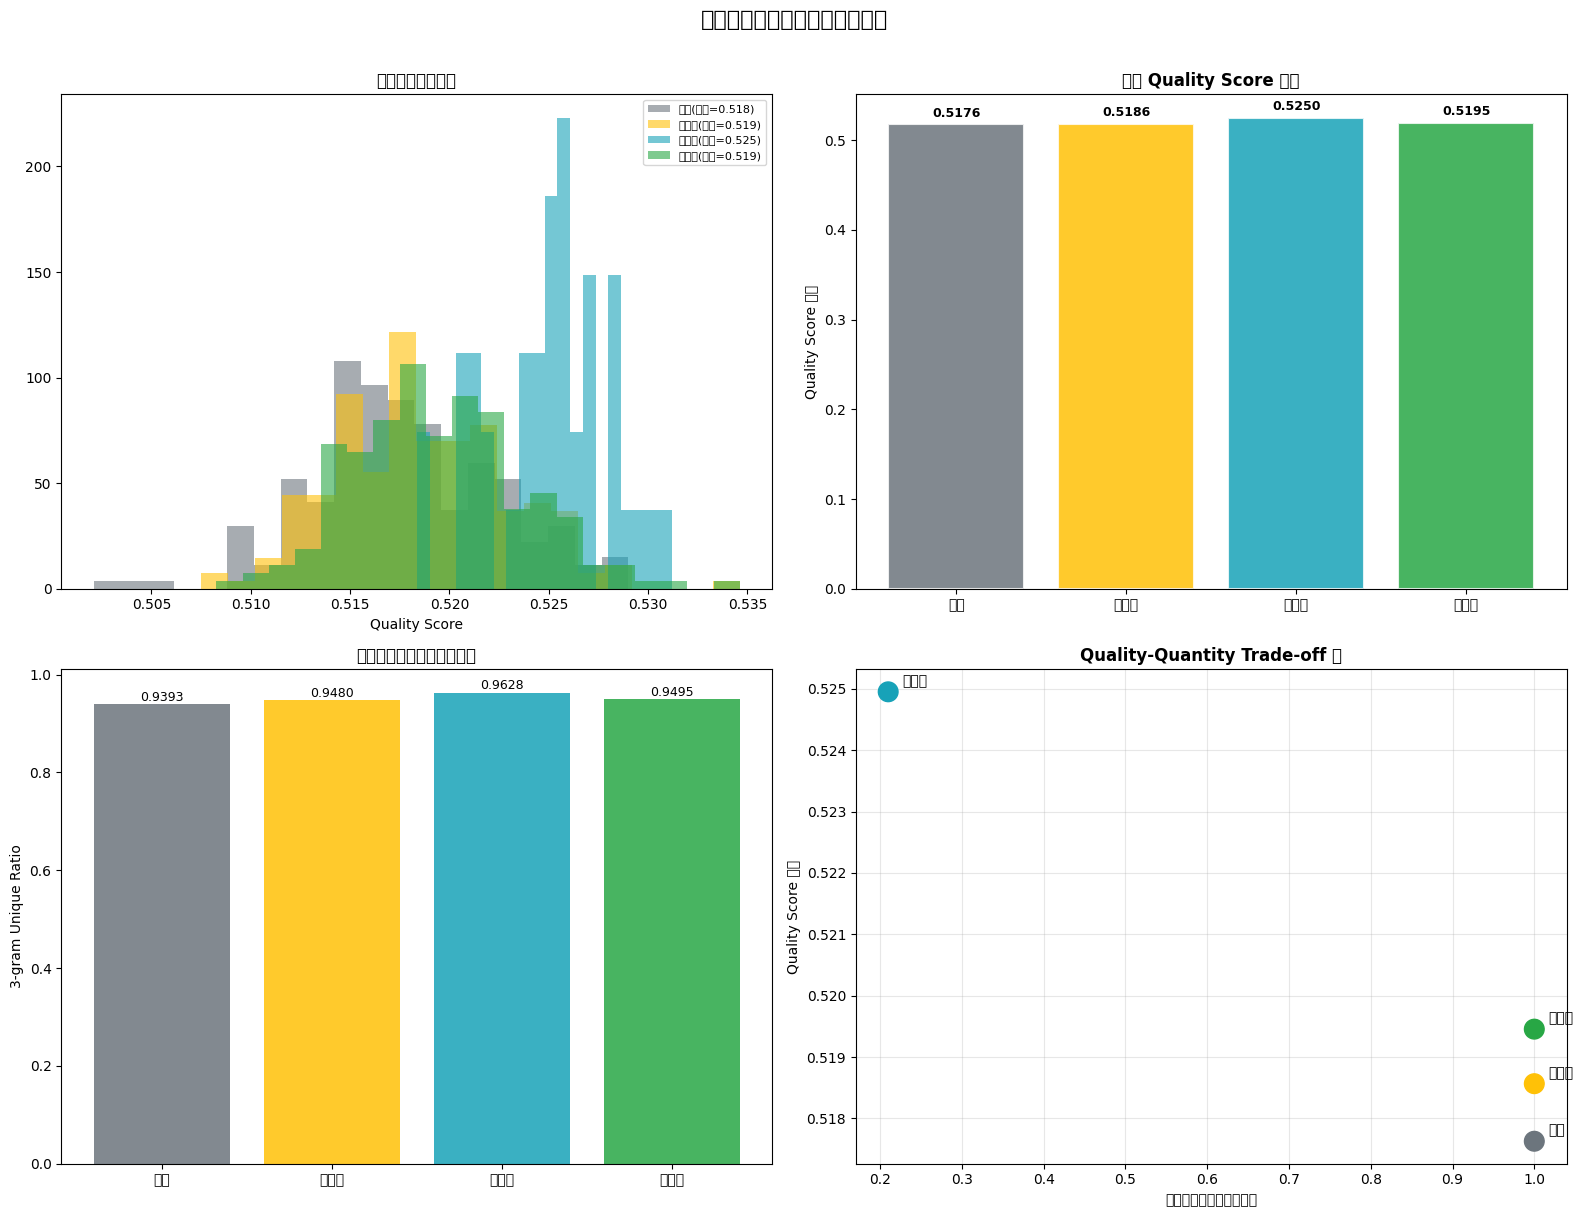

In [5]:
# 质量分布对比图
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

gen_colors = {'raw': '#6c757d', 'gen1': '#ffc107', 'gen2': '#17a2b8', 'gen3': '#28a745'}
gen_labels = {'raw': '原始', 'gen1': '第一代', 'gen2': '第二代', 'gen3': '第三代'}

# 左上：质量分数分布
for k, e in evals.items():
    axes[0, 0].hist(e['quality_scores'], bins=20, alpha=0.6, 
                     label=f"{gen_labels[k]}(均值={e['quality_mean']:.3f})",
                     color=gen_colors[k], density=True)
axes[0, 0].set_xlabel('Quality Score')
axes[0, 0].set_title('质量分数分布对比', fontweight='bold')
axes[0, 0].legend(fontsize=8)

# 右上：Quality Score 均值柱状图
gen_names = [gen_labels[k] for k in evals]
quality_means = [evals[k]['quality_mean'] for k in evals]
bars = axes[0, 1].bar(gen_names, quality_means, color=list(gen_colors.values()), 
                        alpha=0.85, edgecolor='white', linewidth=1.5)
for bar, val in zip(bars, quality_means):
    axes[0, 1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9, fontweight='bold')
axes[0, 1].set_ylabel('Quality Score 均值')
axes[0, 1].set_title('各代 Quality Score 对比', fontweight='bold')

# 左下：多样性对比
diversity_trigram = [evals[k]['trigram_diversity'] for k in evals]
bars2 = axes[1, 0].bar(gen_names, diversity_trigram, color=list(gen_colors.values()), alpha=0.85)
for bar, val in zip(bars2, diversity_trigram):
    axes[1, 0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                     f'{val:.4f}', ha='center', va='bottom', fontsize=9)
axes[1, 0].set_ylabel('3-gram Unique Ratio')
axes[1, 0].set_title('数据多样性（越高越多样）', fontweight='bold')

# 右下：Quality-Quantity trade-off
raw_count = evals['raw']['doc_count']
retention_rates = [evals[k]['doc_count'] / raw_count for k in evals]
quality_vals = [evals[k]['quality_mean'] for k in evals]

axes[1, 1].scatter(retention_rates, quality_vals, 
                    c=list(gen_colors.values()), s=200, zorder=5)
for i, (k, e) in enumerate(evals.items()):
    axes[1, 1].annotate(gen_labels[k], 
                         (retention_rates[i], quality_vals[i]),
                         textcoords='offset points', xytext=(10, 5), fontsize=10)
axes[1, 1].set_xlabel('数据保留率（相对原始）')
axes[1, 1].set_ylabel('Quality Score 均值')
axes[1, 1].set_title('Quality-Quantity Trade-off 图', fontweight='bold')
axes[1, 1].grid(True, alpha=0.3)

plt.suptitle('三代预训练数据清洗方法论对比', fontsize=16, fontweight='bold', y=1.01)
plt.tight_layout()
plt.savefig('../results/figures/06_cross_generation_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

## Cell Group F: 最终结论

### 每一代的适用场景

| 场景 | 推荐选择 | 原因 |
|---|---|---|
| 快速基线验证 | 第一代 | 无需训练，10分钟内可用 |
| 短 token horizon（<5T token）训练 | 第二代 | 最高质量，数据量够用 |
| 长 token horizon（15T+ token）训练 | 第三代 | 高质量+足够多的 unique token |
| 资源受限（无 API Key）| 第一代 + 第二代 | 无需 LLM API |

### 对 TikTok 内容安全场景的启示

1. **数据质量 vs 数量的 trade-off 在任何 ML 任务中都存在**：
   TikTok 内容审核的训练数据同样面临这个问题——
   高精度标注数据少（贵），弱标注数据多（量大但噪声多）。
   
2. **分类器集成是提升 recall 的通用手段**：
   单一内容安全分类器会有漏判，多分类器 union 能扩大覆盖面。
   
3. **合成数据改写 ≈ 数据增强**：
   对于罕见的有害内容类型（数据稀少），LLM 改写/合成是获取更多训练数据的可行方案。

In [6]:
# 保存最终对比结果
import json
comparison_results = {}
for k, e in evals.items():
    comparison_results[k] = {k2: v for k2, v in e.items() if k2 != 'quality_scores'}

Path('../results/reports').mkdir(parents=True, exist_ok=True)
with open('../results/reports/cross_generation_comparison.json', 'w') as f:
    json.dump(comparison_results, f, ensure_ascii=False, indent=2, default=float)

print("✅ 对比结果已保存: results/reports/cross_generation_comparison.json")
print()
print("运行对比报告脚本：")
print("  python scripts/generate_comparison_report.py")

✅ 对比结果已保存: results/reports/cross_generation_comparison.json

运行对比报告脚本：
  python scripts/generate_comparison_report.py
